# Topographic-dominated eddies: polarity-dependent response to signed PV gradients

## Corrected hypothesis

For signed $PV=(\zeta+f)/h$, AEs are predicted to **align** with $\nabla PV$ ($\Delta\theta\to0^\circ$), whereas CEs are predicted to **oppose** it ($\Delta\theta\to180^\circ$).

The CE transition is: natural poleward tilt → departure as total signed $\nabla PV$ rotates → increasing opposition to the signed topographic gradient. The secondary AE hypothesis is that shelf proximity disrupts its otherwise aligned response. That mechanism must be tested separately rather than inferred from a broad distribution alone.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

## 1. Load data and define the topographic-dominated population

In [2]:
DOMINANCE_FACTOR = 2.0
MAX_DEPTH_m = 3000.0
MIN_TILT_km = 5.0
ALIGNMENT_DEG = 45.0
RANDOM_TOLERANCE_FRACTION = ALIGNMENT_DEG / 180.0
SHELF_LON = 154.75

ELLIPSE_FRAC= .75

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = tilt.add_region_labels(df, grid)
df = tilt.add_pv_gradient_terms(df, grid, core_mean=True, frac=ELLIPSE_FRAC)

config = PVAlignmentConfig(
    dominance_factor=DOMINANCE_FACTOR, max_topo_depth_m=MAX_DEPTH_m,
    min_tilt_distance_km=MIN_TILT_km,
)
d = add_pv_alignment_diagnostics(df, config)
assert d.beta.dropna().median() > 0, 'Expected positive planetary beta after gradient sign correction.'
topographic = d[d.shallow_ocean_topographic & d.direction_valid].copy()
topographic = topographic[np.isfinite(topographic.PV_grad_mag) & (topographic.PV_grad_mag > 0)]
topographic['log_PV_grad_mag'] = np.log(topographic.PV_grad_mag)
topographic['raw_signed_PV_mismatch'] = topographic.dtheta_PV_grad
topographic['preference_error'] = np.where(topographic.Cyc.eq('AE'),
    topographic.raw_signed_PV_mismatch, 180.0-topographic.raw_signed_PV_mismatch)
topographic['within_tolerance'] = topographic.preference_error <= ALIGNMENT_DEG
topographic['response_cosine'] = np.cos(np.deg2rad(topographic.raw_signed_PV_mismatch))
topographic['shelf_class'] = np.where(topographic.lon < SHELF_LON, 'On-shelf', 'Off-shelf')

display(topographic.groupby(['Cyc', 'shelf_class']).agg(
    observations=('Eddy', 'size'), eddies=('Eddy', 'nunique'),
    median_PV_grad=('PV_grad_mag', 'median'), median_raw_mismatch_deg=('raw_signed_PV_mismatch','median'),
    median_preference_error_deg=('preference_error','median'),
    within_tolerance_fraction=('within_tolerance','mean')
).round(3))

observations  eddies  median_PV_grad  \
Cyc shelf_class                                         
AE  Off-shelf            5073     290             0.0   
    On-shelf              930      75             0.0   
CE  Off-shelf            5799     309             0.0   
    On-shelf             2748     272             0.0   

                 median_raw_mismatch_deg  median_preference_error_deg  \
Cyc shelf_class                                                         
AE  Off-shelf                     92.627                       92.627   
    On-shelf                     111.690                      111.690   
CE  Off-shelf                    116.123                       63.877   
    On-shelf                     146.718                       33.282   

                 within_tolerance_fraction  
Cyc shelf_class                             
AE  Off-shelf                        0.244  
    On-shelf                         0.151  
CE  Off-shelf                        0.395  
    On-shelf                         0.626

In [3]:
topographic.head()

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region,h,f,beta,dhdx,dhdy,abs_vort,...,PV_grad_plan_theta,PV_grad_topo_mag,PV_grad_topo_theta,PV_grad_mag,PV_grad_theta,dtheta_PV_grad,dtheta_PV_grad_topo,dtheta_PV_grad_plan,Ro,topo_plan_ratio,topo_plan_ratio_smooth,ellipse_frac,ellipse_inner_frac,ellipse_area_fraction,pv_averaging,planetary_strong,open_ocean_planetary,topographic_strong,shallow_ocean_topographic,signed_dtheta_PV_grad,expected_PV_theta,expected_direction_error,direction_valid,expected_match,log_PV_grad_mag,raw_signed_PV_mismatch,preference_error,within_tolerance,response_cosine,shelf_class
118,4,1493,CE,150.518728,-37.464100,92,42,244.562541,208.329230,-0.000050,-0.000021,1.734126,-0.362949,0.657316,37.677021,14.865502,1.837577,22.337952,36,1994-02-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,7.652775,231.141407,S2,2933.821584,-0.000089,1.842822e-11,0.102119,-0.017159,-0.000139,...,0.0,3.539557e-12,101.366903,3.538079e-12,101.247247,129.894160,129.774503,128.858593,0.564763,6.151967,6.151967,0.75,0.0,0.5625,nonlinear,False,False,True,True,129.894160,281.247247,50.105840,True,False,-26.367437,129.894160,50.105840,False,-0.641371,On-shelf
119,4,1494,CE,150.430296,-37.456043,89,42,236.888864,206.512995,-0.000052,-0.000021,1.618557,-0.563463,0.878391,37.197425,13.298593,1.829614,22.925006,36,1994-02-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,7.981880,243.521114,S2,2067.530283,-0.000089,1.843084e-11,0.106900,-0.019417,-0.000140,...,0.0,1.216155e-11,102.581358,1.215822e-11,102.510966,141.010148,140.939755,116.478886,0.584176,6.677866,6.526676,0.75,0.0,0.5625,nonlinear,False,False,True,True,141.010148,282.510966,38.989852,True,True,-25.133016,141.010148,38.989852,True,-0.777257,On-shelf
450,9,1465,AE,159.688237,-33.109608,257,193,901.623234,952.329053,0.000032,0.000016,1.051871,0.150987,0.979315,69.182816,-37.989613,1.166617,47.513203,65,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,16.344476,80.566298,D2,2592.604228,-0.000080,1.939852e-11,-0.031167,0.002309,-0.000047,...,0.0,2.462900e-13,273.064322,2.468391e-13,274.897613,165.668684,167.501976,80.566298,-0.404852,3.438627,3.438627,0.75,0.0,0.5625,nonlinear,False,False,True,True,165.668684,274.897613,165.668684,True,False,-29.030040,165.668684,165.668684,False,-0.968881,Off-shelf
451,9,1466,AE,159.561638,-32.983136,254,195,886.519054,961.661738,0.000033,0.000016,0.946863,0.059177,1.094231,65.871209,-35.605415,1.097318,43.471328,65,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,19.693589,63.661540,U2,2959.609643,-0.000079,1.942668e-11,-0.031053,0.004270,-0.000046,...,0.0,1.941075e-13,277.237987,1.950900e-13,279.236225,144.425316,146.423553,63.661540,-0.422071,3.343115,3.343115,0.75,0.0,0.5625,nonlinear,False,False,True,True,144.425316,279.236225,144.425316,True,False,-29.265315,144.425316,144.425316,False,-0.813358,Off-shelf
571,11,1466,AE,159.246943,-29.608348,231,265,754.794270,1308.572099,0.000021,0.000009,1.476579,-0.529597,0.906262,84.451550,-35.450726,1.743325,56.748472,60,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,19.957088,335.597775,U2,2566.346092,-0.000072,2.011277e-11,0.000060,0.002537,-0.000051,...,0.0,1.765745e-14,10.800310,2.548951e-14,7.458558,31.860784,35.202535,24.402225,-0.293867,0.800608,0.707982,0.75,0.0,0.5625,nonlinear,False,False,True,True,-31.860784,7.458558,31.860784,True,True,-31.300509,31.860784,31.860784,True,0.849333,Off-shelf


## 2. First verify the claimed AE–CE gradient contrast

The six-fold contrast is treated as an empirical claim to estimate, not as an input assumption. Medians are calculated per eddy before comparing polarities.

,median_PV_grad,observations
Cyc,,
AE,1.340680e-13,6003.0
CE,2.577259e-13,8547.0


Ratio of CE to AE median eddy-level |∇PV|: 1.92


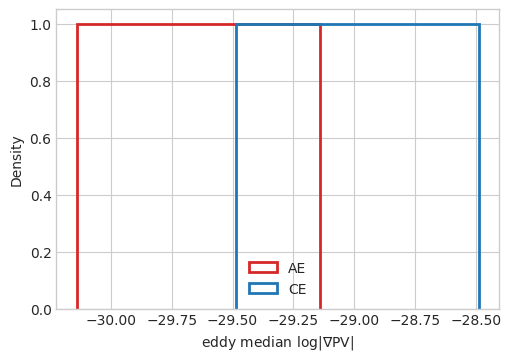

In [4]:
eddy_pv = (topographic.groupby('Cyc', as_index=False)
           .agg(median_PV_grad=('PV_grad_mag', 'median'),
                observations=('Day', 'size')))
pv_summary = eddy_pv.groupby('Cyc').median(numeric_only=True)
display(pv_summary)
ce_ae_ratio = (pv_summary.loc['CE', 'median_PV_grad'] / pv_summary.loc['AE', 'median_PV_grad'])
print(f'Ratio of CE to AE median eddy-level |∇PV|: {ce_ae_ratio:.2f}')

fig, ax = plt.subplots(figsize=(5, 3.5), constrained_layout=True)
for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
    x = np.log(eddy_pv.loc[eddy_pv.Cyc == cyc, 'median_PV_grad'])
    ax.hist(x, bins='fd', density=True, histtype='step', lw=2, color=color, label=cyc)
ax.set(xlabel=r'eddy median $\log |\nabla \mathrm{PV}|$', ylabel='Density')
ax.legend(frameon=False);

## 3. Map and alignment distributions

A common normalization is used for the AE and CE maps. Separate colour families identify polarity, but equal normalized intensity represents equal `log|∇PV|`.

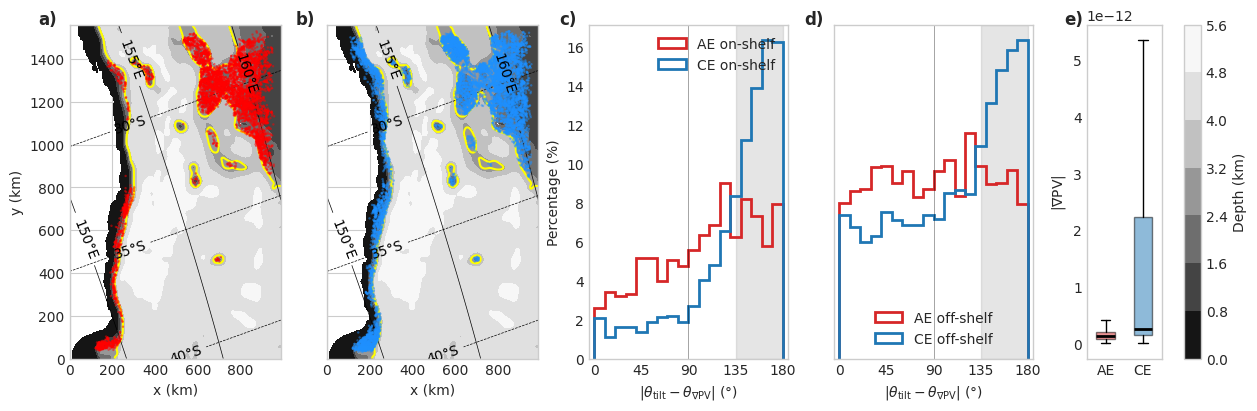

In [5]:
fig,axs=plt.subplots(1,5,figsize=(12.5,4),width_ratios=[1,1,.8,.8,.3],constrained_layout=True)

for ax,cyc in zip(axs[:2],['AE','CE']):
    d=topographic[topographic.Cyc==cyc]
    bath=ax.contourf(grid.X_grid,grid.Y_grid,np.where(grid.mask_rho,grid.h/1e3,np.nan),cmap='Greys_r')
    ax.scatter(d.xc,d.yc,s=3,c='r' if cyc=='AE' else 'dodgerblue',alpha=.5,edgecolors='none',zorder=3)
    ax.contour(grid.X_grid,grid.Y_grid,grid.h,levels=[MAX_DEPTH_m],colors='yellow',zorder=2)
    tilt.lat_lon_contours(ax,grid); ax.set(xlabel='x (km)',aspect='equal')
axs[0].set_ylabel('y (km)'); axs[1].set_yticklabels([])

bins=np.arange(0,181,10)
for ax,(name,d) in zip(axs[2:4],[('on-shelf',topographic[topographic.lon<154.75]),('off-shelf',topographic[topographic.lon>154.75])]):
    for cyc,c in [('AE','tab:red'),('CE','tab:blue')]:
        x=d.loc[d.Cyc==cyc,'dtheta_PV_grad'].dropna()
        ax.hist(x,bins=bins,weights=np.ones(len(x))*100/len(x),histtype='step',lw=2,color=c,label=f'{cyc} {name}')
    ax.set(xlim=(-5,185),xticks=[0,45,90,135,180],xlabel=r'$|\theta_{\rm tilt}-\theta_{\nabla\rm PV}|$ (°)')
    ax.axvspan(180-ALIGNMENT_DEG,180,color='grey',alpha=.2); ax.axvline(90,lw=.5,alpha=.5,c='k'); ax.grid(False)
    ax.legend(frameon=False,loc='upper right' if name=='on-shelf' else 'lower center')
axs[2].set_ylabel('Percentage (%)'); axs[3].set_yticklabels([])

ax=axs[4]
bp=ax.boxplot([topographic.loc[topographic.Cyc==c,'PV_grad_mag'].dropna() for c in ['AE','CE']],
              tick_labels=['AE','CE'],showfliers=False,patch_artist=True,widths=.5)
for b,c in zip(bp['boxes'],['tab:red','tab:blue']): b.set(facecolor=c,alpha=.5)
for m in bp['medians']: m.set(color='k',lw=2)
ax.set_ylabel(r'$|\nabla \mathrm{PV}|$'); ax.grid(False)

for ax,l in zip(axs,'abcde'): ax.text(-.3 if l=='e' else -.15,1,f'{l})',transform=ax.transAxes,fontweight='bold',fontsize=12)

fig.colorbar(bath,ax=axs,orientation='vertical',fraction=.025,pad=.02,label='Depth (km)')
plt.show()

## 4. Primary test: conditional polarity response versus PV-gradient magnitude

Equal-population bins show both the median angular mismatch and the probability of the polarity-predicted response. A forcing threshold would appear as a relatively abrupt decline in angle and rise in alignment probability, especially for AEs. A smooth trend would instead support progressive constraint without a sharp threshold.

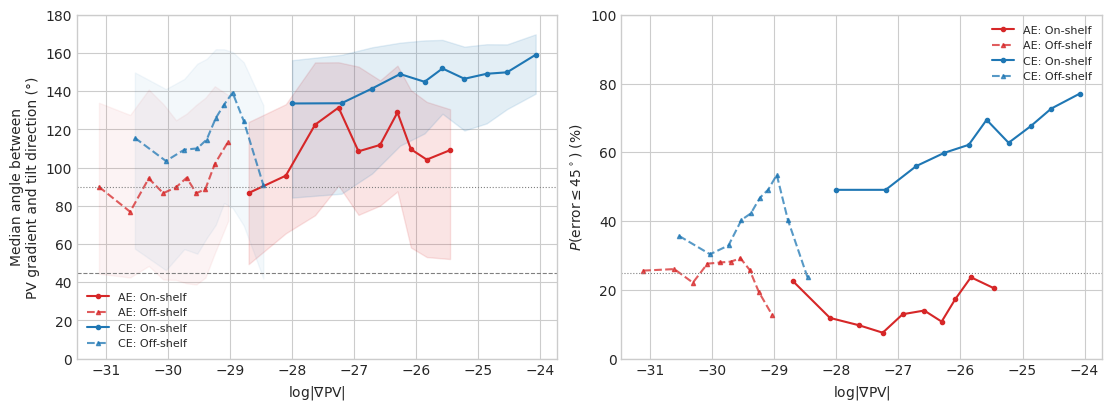

In [6]:
def binned_alignment(d,n=10):
    d=d.copy(); d['bin']=pd.qcut(d.log_PV_grad_mag,n,duplicates='drop')
    return d.groupby('bin',observed=True).agg(logPV=('log_PV_grad_mag','median'),angle=('dtheta_PV_grad','median'),
        q25=('dtheta_PV_grad',lambda x:x.quantile(.25)),q75=('dtheta_PV_grad',lambda x:x.quantile(.75)),
        p=('within_tolerance','mean')).reset_index(drop=True)

styles={'On-shelf':('-','o',1),'Off-shelf':('--','^',.75)}
colors={'AE':'tab:red','CE':'tab:blue'}; cmaps={'AE':plt.cm.Reds,'CE':plt.cm.Blues}
tilt_bins=[(5,10,'5–10 km',.4),(10,20,'10–20 km',.62),(20,np.inf,'≥20 km',.85)]
fig,axs=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)

for cyc,c in colors.items():
    for shelf,(ls,m,a) in styles.items():
        d=topographic[(topographic.Cyc==cyc)&(topographic.shelf_class==shelf)]
        if d.Eddy.nunique()<10: continue
        s=binned_alignment(d); kw=dict(c=c,ls=ls,marker=m,alpha=a,ms=3,lw=1.5,label=f'{cyc}: {shelf}')
        axs[0].plot(s.logPV,s.angle,**kw); axs[0].fill_between(s.logPV,s.q25,s.q75,color=c,alpha=.12 if shelf=='On-shelf' else .05)
        axs[1].plot(s.logPV,100*s.p,**kw)

axs[0].axhline(90,c='.5',ls=':',lw=.8); axs[0].axhline(ALIGNMENT_DEG,c='.5',ls='--',lw=.8)
axs[1].axhline(100*RANDOM_TOLERANCE_FRACTION,c='.5',ls=':',lw=.8)
axs[0].set(xlabel=r'$\log |\nabla \mathrm{PV}|$',ylabel='Median angle between\nPV gradient and tilt direction (°)',ylim=(0,180))
axs[1].set(xlabel=r'$\log |\nabla \mathrm{PV}|$',ylabel=rf'$P(\mathrm{{error}}\leq{ALIGNMENT_DEG:.0f}^\circ)$ (%)',ylim=(0,100))
for ax in axs: ax.legend(frameon=False,fontsize=8)

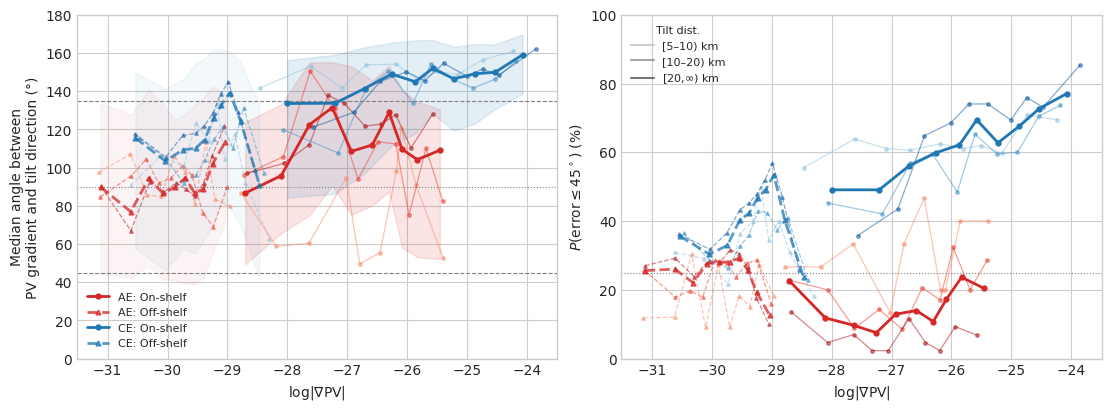

In [7]:
from matplotlib.lines import Line2D

styles={'On-shelf':('-','o',1),'Off-shelf':('--','^',.75)}
colors={'AE':'tab:red','CE':'tab:blue'}; cmaps={'AE':plt.cm.Reds,'CE':plt.cm.Blues}
tilt_bins=[(5,10,'[5–10) km',.4),(10,20,'[10–20) km',.62),(20,np.inf,r'[20,$\infty$) km',.85)]
fig,axs=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)

for cyc,c in colors.items():
    for shelf,(ls,m,a) in styles.items():
        base=topographic[(topographic.Cyc==cyc)&(topographic.shelf_class==shelf)]
        if base.Eddy.nunique()<10: continue
        s=binned_alignment(base); kw=dict(c=c,ls=ls,marker=m,alpha=a,ms=3.5,lw=2,label=f'{cyc}: {shelf}',zorder=4)
        axs[0].plot(s.logPV,s.angle,**kw); axs[0].fill_between(s.logPV,s.q25,s.q75,color=c,alpha=.12 if shelf=='On-shelf' else .05,zorder=1)
        axs[1].plot(s.logPV,100*s.p,**kw)

        for lo,hi,_,shade in tilt_bins:
            d=base[(base.TiltDis>=lo)&(base.TiltDis<hi)]
            if d.Eddy.nunique()<10: continue
            sb=binned_alignment(d); fc=cmaps[cyc](shade)
            kw=dict(c=fc,ls=ls,marker=m,ms=2.5,lw=.9,alpha=.5,zorder=2)
            axs[0].plot(sb.logPV,sb.angle,**kw); axs[1].plot(sb.logPV,100*sb.p,**kw)

axs[0].axhline(90,c='.5',ls=':',lw=.8); axs[0].axhline(ALIGNMENT_DEG,c='.5',ls='--',lw=.8); axs[0].axhline(180-ALIGNMENT_DEG,c='.5',ls='--',lw=.8)
axs[1].axhline(100*RANDOM_TOLERANCE_FRACTION,c='.5',ls=':',lw=.8)
axs[0].set(xlabel=r'$\log |\nabla \mathrm{PV}|$',ylabel='Median angle between\nPV gradient and tilt direction (°)',ylim=(0,180))
axs[1].set(xlabel=r'$\log |\nabla \mathrm{PV}|$',ylabel=rf'$P(\mathrm{{error}}\leq{ALIGNMENT_DEG:.0f}^\circ)$ (%)',ylim=(0,100))
axs[0].legend(frameon=False,fontsize=8)
axs[1].legend(handles=[Line2D([0],[0],c=plt.cm.Greys(s),lw=1.5,alpha=.65,label=l) for *_,l,s in tilt_bins],
              title='Tilt dist.',frameon=False,fontsize=8,title_fontsize=8)

AEs: tilt likes to stay perpendicular to the slope \
as the PV gradient gets bigger, the AE actually begins to tilt onto the slope (contradictory to what we would expect)\
CEs: as the PV gradient gets bigger, the CEs tilt more onto the slope

It seems like on sharp slopes, like the edges of shallow areas or seamounts, the CEs dont isntantly tilt onto the slopes.\
It may be too abrupt the change. But onces they are settled, they like to tilt onto the slope.

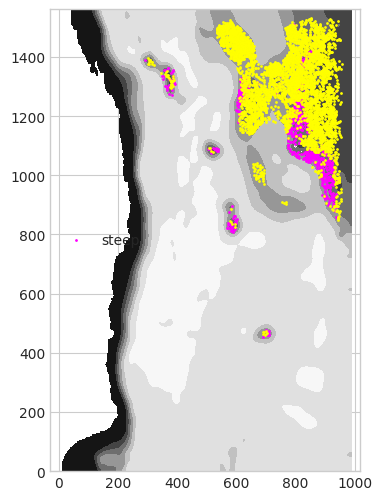

In [8]:
fig, ax = plt.subplots(figsize=(4,6))
STEEP_THRESH = -28.8
ax.contourf(grid.X_grid, grid.Y_grid, np.where(grid.mask_rho, grid.h / 1e3, np.nan), cmap='Greys_r')
df_ = topographic[(topographic.shelf_class=='Off-shelf')&(topographic.Cyc=='CE')&(topographic.log_PV_grad_mag>=STEEP_THRESH)]
ax.scatter(df_.xc, df_.yc, s=1, color='magenta', label='steep')
df_ = topographic[(topographic.shelf_class=='Off-shelf')&(topographic.Cyc=='CE')&(topographic.log_PV_grad_mag<=STEEP_THRESH)]
ax.scatter(df_.xc, df_.yc, s=1, color='yellow')
ax.axis('equal'); ax.legend(loc='center left')

(array([128.,  32.,  37.,  16.,  29.,  47.,  36.,  36.,  26., 194.]),
 array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, -0. ]),
 <BarContainer object of 10 artists>)

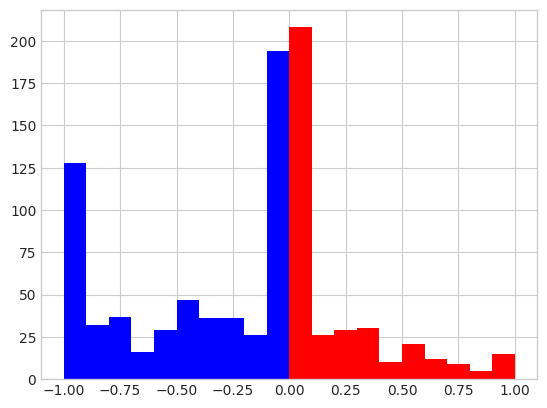

In [9]:
frac_ae = (topographic[topographic.Cyc.eq('AE')].groupby('Eddy').dtheta_PV_grad
           .apply(lambda x: (x.dropna() < 45).mean()))

frac_ce = (topographic[topographic.Cyc.eq('CE')].groupby('Eddy').dtheta_PV_grad
           .apply(lambda x: (x.dropna() > 135).mean()))

plt.hist(frac_ae, color='r')
plt.hist(-frac_ce, color='b')

## 5. Does tilt magnitude change the result?

The 5 km cutoff removes the least meaningful bearings. This sensitivity plot repeats the relationship for progressively larger tilt displacements; a physical alignment signal should not be created solely by the cutoff.

TypeError: binned_alignment() got an unexpected keyword argument 'n_bins'

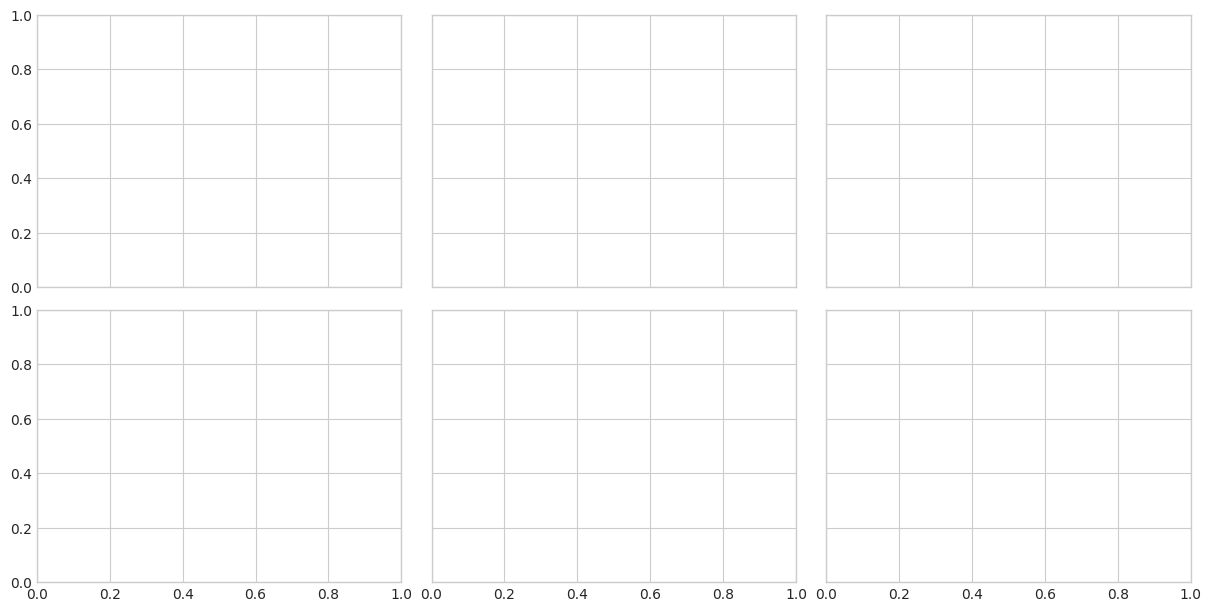

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharex='col', sharey=True, constrained_layout=True)
for j, min_tilt in enumerate([5, 10, 20]):
    for i, (cyc, color) in enumerate([('AE', 'tab:red'), ('CE', 'tab:blue')]):
        part = topographic[(topographic.Cyc == cyc) & (topographic.TiltDis >= min_tilt)]
        stats = binned_alignment(part, n_bins=10)
        axs[i, j].plot(stats.logPV, 100 * stats.p_aligned, '-o', color=color)
        axs[i, j].axhline(100 * RANDOM_TOLERANCE_FRACTION, color='0.5', ls=':', lw=.8)
        axs[i, j].set(title=f'{cyc}: TiltDis ≥ {min_tilt} km', ylim=(0, 100))
        if i == 1: axs[i, j].set_xlabel(r'$\log |\nabla \mathrm{PV}|$')
        if j == 0: axs[i, j].set_ylabel('Polarity-predicted observations (%)')

## 6. Eddy-level trend estimates

Estimate one slope per eddy where enough gradient variation exists. The distribution of slopes asks whether the relationship recurs across eddies rather than being driven by a few long tracks. Negative preference-error slopes and positive predicted-response slopes support the hypothesis.

In [ ]:
# cant complete full eddy analysis becaue eddies come in and out of topographic domination

# slope_rows = []
# for (cyc, eddy), part in topographic.groupby(['Cyc', 'Eddy']):
#     if len(part) < 10 or part.log_PV_grad_mag.nunique() < 4:
#         continue
#     angle_slope = np.polyfit(part.log_PV_grad_mag, part.preference_error, 1)[0]
#     aligned_slope = np.polyfit(part.log_PV_grad_mag, part.within_tolerance.astype(float), 1)[0]
#     slope_rows.append({'Cyc': cyc, 'Eddy': eddy, 'n': len(part),
#                        'angle_slope_deg_per_logPV': angle_slope,
#                        'response_slope_per_logPV': aligned_slope})
# slopes = pd.DataFrame(slope_rows)
# display(slopes.groupby('Cyc').agg(
#     eddies=('Eddy', 'size'), median_angle_slope=('angle_slope_deg_per_logPV', 'median'),
#     fraction_negative_angle=('angle_slope_deg_per_logPV', lambda x: (x < 0).mean()),
#     median_alignment_slope=('response_slope_per_logPV', 'median'),
#     fraction_positive_alignment=('response_slope_per_logPV', lambda x: (x > 0).mean())
# ).round(3))

## 7. Interpretation and next statistical model

A convincing result requires agreement among: (1) binned angle distributions, (2) alignment probability, (3) tilt-distance sensitivity, and (4) within-eddy slopes. A formal follow-up should use a mixed-effects or clustered model with eddy as the grouping unit, allow nonlinear dependence on `log|∇PV|`, and test a polarity-by-gradient interaction. A segmented model should only be used to claim a threshold if it materially improves out-of-sample fit over a smooth monotonic alternative.